# Background Sequence Analysis\n",
Read background FASTA, run AkitaPT, and visualise predicted contact maps as a grid.

In [1]:
import sys
import os
import re

import numpy as np
import matplotlib.pyplot as plt
import torch

sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))
sys.path.insert(0, os.path.abspath("/home1/smaruj/akita_semifreddo/"))

from utils.model_utils import load_model
from utils.data_utils import one_hot_encode_sequence, from_upper_triu

## Config

In [2]:
FASTA_PATH = (
    "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita"
    "/analysis/background_generation/background_sequences_scd30_totvar1300.fasta"
)
MODEL_CKPT = (
    "/home1/smaruj/pytorch_akita/models/finetuned/mouse/Hsieh2019_mESC"
    "/checkpoints/Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth"
)

MATRIX_LEN = 512
NUM_DIAGS  = 2
VMIN, VMAX = -0.6, 0.6
NCOLS      = 5   # columns in the grid

## 1. Read FASTA

In [3]:
def read_fasta(path):
    """Return list of (header, sequence) tuples."""
    records = []
    header, seq_parts = None, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(seq_parts)))
                header, seq_parts = line[1:], []
            else:
                seq_parts.append(line)
    if header is not None:
        records.append((header, "".join(seq_parts)))
    return records

records = read_fasta(FASTA_PATH)
headers, sequences = zip(*records)
print(f"Loaded {len(records)} sequences")
print("Example header:", headers[0])

Loaded 10 sequences
Example header: shuffled_0_chrchr8_76333056_77643776_scd29.26_totvar=1226.68


## 2. Load model

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = load_model(MODEL_CKPT, device)
model.eval()
print("Model loaded.")

Using device: cuda:0
Model loaded.


## 3. Run predictions

In [6]:
all_preds = []   # upper-triu tensors, one per sequence

with torch.no_grad():
    for i, seq in enumerate(sequences):
        one_hot = one_hot_encode_sequence(seq)
        batch   = torch.from_numpy(one_hot).to(device)  # (1, 4, L)
        preds   = model(batch).cpu().squeeze(0)                       # (n_triu,)
        all_preds.append(preds.numpy())
        print(f"  [{i+1:>2}/{len(sequences)}] done")

all_preds = np.stack(all_preds)   # (N, n_triu)
print(f"\nPredictions shape: {all_preds.shape}")

/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


  [ 1/10] done
  [ 2/10] done
  [ 3/10] done
  [ 4/10] done
  [ 5/10] done
  [ 6/10] done
  [ 7/10] done
  [ 8/10] done
  [ 9/10] done
  [10/10] done

Predictions shape: (10, 1, 130305)


## 4. Plot contact map grid

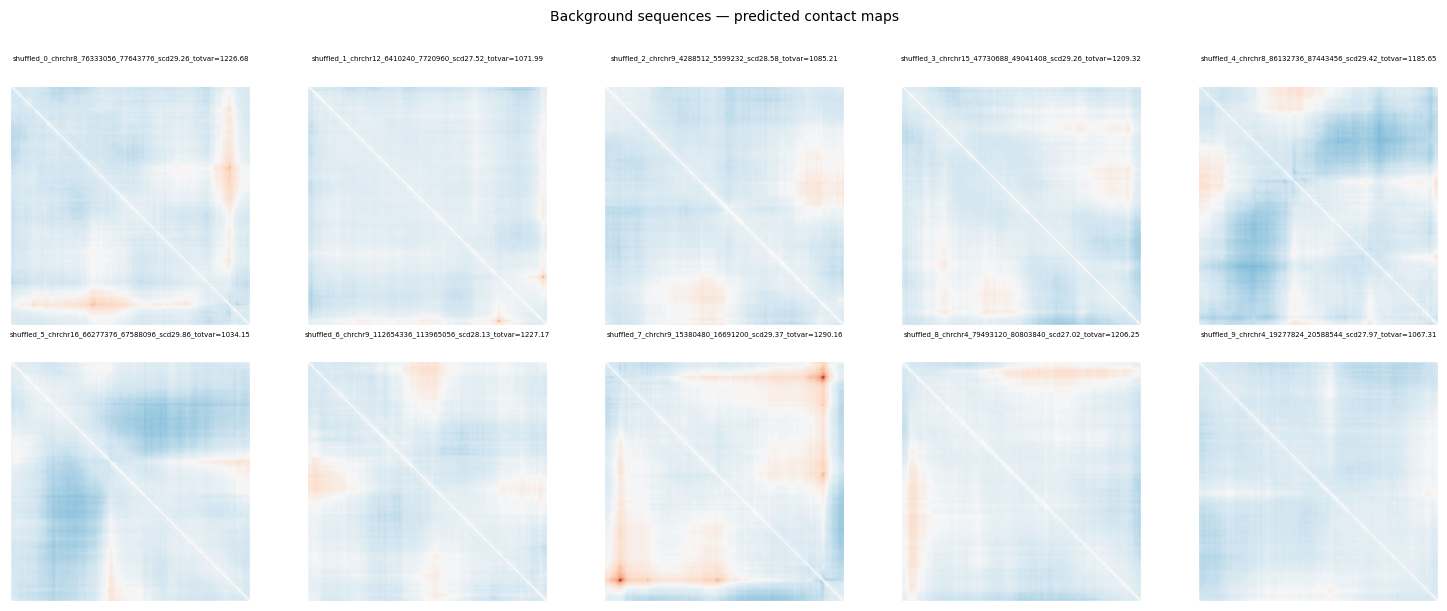

In [7]:
n      = len(all_preds)
ncols  = min(NCOLS, n)
nrows  = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes = np.array(axes).reshape(-1)  # flatten for easy indexing

for i in range(n):
    mat = from_upper_triu(all_preds[i], matrix_len=MATRIX_LEN, num_diags=NUM_DIAGS)
    axes[i].matshow(mat.astype(np.float16), cmap="RdBu_r", vmin=VMIN, vmax=VMAX)
    axes[i].set_title(headers[i], fontsize=5, pad=2)
    axes[i].axis("off")

# hide unused axes
for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Background sequences — predicted contact maps", fontsize=10, y=1.01)
plt.tight_layout()
# plt.savefig("background_contact_maps.svg", format="svg", bbox_inches="tight")
plt.show()